## Introduction

This notebook compares **Scenario C** solutions from:
- **Classical baseline** (`09b_qubo_scenario_C_classical_baseline.ipynb`)
- **AWS Braket SV1 QAOA** (`09c_aws_braket_qaoa_scenario_C_sv1.ipynb`)

Primary deliverables:
- A tidy **comparison table** (objective/energy + feasibility columns if available)
- **Jaccard overlap** between selected trial sets
- One **portfolio-ready figure** saved to `outputs/figures/`

Outputs:
- `data/results/09d_compare_classical_vs_sv1_scenario_C.csv`
- `data/results/09d_overlap_classical_vs_sv1_scenario_C.csv`
- `outputs/figures/09d_scenario_C_compare_selected_count_and_energy.png`

Notes:
- This notebook is defensive about column names and file paths, since artifacts may differ slightly across notebook versions.


In [4]:
# ============================================================
# Cell 1 — Setup: imports, paths, and required artifacts (Scenario C)
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Project directories ---
RESULTS_DIR = Path("data/results")
FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Scenario C artifacts (SV1 from 09c) ---
PATH_SV1_BEST     = RESULTS_DIR / "_09c_sv1_best_scenario_C.json"
PATH_SV1_SUMMARY  = RESULTS_DIR / "09c_sv1_summary_scenario_C.csv"
PATH_SV1_SELECTED = RESULTS_DIR / "09c_sv1_selected_trials_scenario_C.csv"

# --- Scenario C artifacts (Classical from 09b) ---
# NOTE: Your repo writes CSV + best_bitstring.txt (not JSON)
PATH_CLASS_SUMMARY  = RESULTS_DIR / "09b_scenario_C_classical_summary.csv"
PATH_CLASS_SELECTED = RESULTS_DIR / "09b_scenario_C_classical_selected_trials.csv"
PATH_CLASS_BITTXT   = RESULTS_DIR / "09b_scenario_C_classical_best_bitstring.txt"

# --- Outputs (09d) ---
OUT_COMPARE = RESULTS_DIR / "09d_compare_classical_vs_sv1_scenario_C.csv"
OUT_OVERLAP = RESULTS_DIR / "09d_overlap_classical_vs_sv1_scenario_C.csv"
OUT_FIG     = FIG_DIR / "09d_scenario_C_compare_selected_count_and_energy.png"

# --- Existence checks ---
missing = []
for p in [PATH_SV1_BEST, PATH_SV1_SUMMARY, PATH_SV1_SELECTED,
          PATH_CLASS_SUMMARY, PATH_CLASS_SELECTED, PATH_CLASS_BITTXT]:
    if not p.exists():
        missing.append(str(p))

if missing:
    raise FileNotFoundError(
        "Missing required Scenario C artifacts:\n- " + "\n- ".join(missing) +
        "\n\nFix: confirm 09b (classical) and 09c (SV1) Scenario C artifacts exist in data/results/."
    )

print("OK: Found required Scenario C artifacts.")
print("SV1:")
print("  best   :", PATH_SV1_BEST)
print("  summary:", PATH_SV1_SUMMARY)
print("  selected:", PATH_SV1_SELECTED)
print("Classical:")
print("  summary:", PATH_CLASS_SUMMARY)
print("  selected:", PATH_CLASS_SELECTED)
print("  best bitstring txt:", PATH_CLASS_BITTXT)
print("Figures dir:", FIG_DIR.resolve())


OK: Found required Scenario C artifacts.
SV1:
  best   : data/results/_09c_sv1_best_scenario_C.json
  summary: data/results/09c_sv1_summary_scenario_C.csv
  selected: data/results/09c_sv1_selected_trials_scenario_C.csv
Classical:
  summary: data/results/09b_scenario_C_classical_summary.csv
  selected: data/results/09b_scenario_C_classical_selected_trials.csv
  best bitstring txt: data/results/09b_scenario_C_classical_best_bitstring.txt
Figures dir: /home/parallels/projects/quantum-clinical-trial-optimization/outputs/figures


### What Cell 1 Just Did

- Defined standard project directories (`data/results`, `outputs/figures`) and created the figures directory if needed.
- Pointed the notebook at the Scenario C artifacts that actually exist in your repo (09b CSVs + best-bitstring text, and 09c SV1 JSON/CSVs).
- Ran strict existence checks so the notebook fails fast if anything required is missing.


In [5]:
# ============================================================
# Cell 2 — Load artifacts + normalize into comparable schema
# ============================================================

import json

# --- Load SV1 artifacts (09c) ---
sv1_best = json.loads(PATH_SV1_BEST.read_text())
sv1_sum = pd.read_csv(PATH_SV1_SUMMARY)
sv1_sel = pd.read_csv(PATH_SV1_SELECTED)

# --- Load Classical artifacts (09b) ---
class_sum = pd.read_csv(PATH_CLASS_SUMMARY)
class_sel = pd.read_csv(PATH_CLASS_SELECTED)

# Selected IDs
sv1_selected_ids = (
    [str(x) for x in sv1_sel["nct_id"].tolist()]
    if "nct_id" in sv1_sel.columns else []
)
class_selected_ids = (
    [str(x) for x in class_sel["nct_id"].tolist()]
    if "nct_id" in class_sel.columns else []
)

# Energies (defensive column detection)
def first_present(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

SV1_ENERGY_COL = first_present(sv1_sum, ["qubo_energy_full", "qubo_energy", "energy_full", "objective", "objective_best"])
CLASS_ENERGY_COL = first_present(class_sum, ["qubo_energy_best", "qubo_energy", "energy", "objective", "objective_best"])

sv1_energy = float(sv1_sum.iloc[0][SV1_ENERGY_COL]) if SV1_ENERGY_COL else float(sv1_best.get("qubo_energy_full", sv1_best.get("qubo_energy_pool_best", np.nan)))
class_energy = float(class_sum.iloc[0][CLASS_ENERGY_COL]) if CLASS_ENERGY_COL else np.nan

# Selected counts
sv1_selected_n = int(sv1_best.get("selected_n", len(sv1_selected_ids)))
class_selected_n = int(class_sum.iloc[0]["selected_n"]) if "selected_n" in class_sum.columns else int(len(class_selected_ids))

# Build compare table
rows = [
    {
        "method": "classical",
        "scenario": "C",
        "energy": class_energy,
        "selected_n": class_selected_n,
        "source_files": f"{PATH_CLASS_SUMMARY.name}, {PATH_CLASS_SELECTED.name}, {PATH_CLASS_BITTXT.name}",
    },
    {
        "method": "sv1_qaoa",
        "scenario": "C",
        "energy": sv1_energy,
        "selected_n": sv1_selected_n,
        "source_files": f"{PATH_SV1_BEST.name}, {PATH_SV1_SUMMARY.name}, {PATH_SV1_SELECTED.name}",
    },
]

compare_df = pd.DataFrame(rows)

# Add useful SV1 metadata if present
for col in ["shots", "n_full", "n_pool", "pool_strategy", "results_json_key"]:
    if col in sv1_sum.columns:
        compare_df.loc[compare_df["method"] == "sv1_qaoa", col] = sv1_sum.iloc[0][col]

display(compare_df)
print("Classical selected IDs:", len(class_selected_ids))
print("SV1 selected IDs:", len(sv1_selected_ids))

,method,scenario,energy,selected_n,source_files,shots,n_full,n_pool,pool_strategy,results_json_key
0,classical,C,NaN,10,"09b_scenario_C_classical_summary.csv, 09b_scen...",NaN,NaN,NaN,NaN,NaN
1,sv1_qaoa,C,-2600.0,4,"_09c_sv1_best_scenario_C.json, 09c_sv1_summary...",100.0,60.0,34.0,best_diag,clinical-trials-data/results/sv1_tasks/scenari...


Classical selected IDs: 10
SV1 selected IDs: 4


### What Cell 2 Just Did

- Loaded Scenario C outputs from:
  - **Classical (09b)**: summary CSV + selected trials CSV
  - **SV1 QAOA (09c)**: best JSON + summary CSV + selected trials CSV
- Standardized both methods into one comparison table with:
  - `energy` (best available) and `selected_n`
- Pulled SV1 run metadata (shots, pool size, pooling strategy) when available.


In [6]:
# ============================================================
# Cell 3 — Compute overlap (Jaccard) + save overlap table
# ============================================================

def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

A = set(class_selected_ids)
B = set(sv1_selected_ids)

overlap_ids = sorted(A & B)

overlap_df = pd.DataFrame({"nct_id": overlap_ids})

overlap_stats = pd.DataFrame([{
    "scenario": "C",
    "method_a": "classical",
    "method_b": "sv1_qaoa",
    "n_a": int(len(A)),
    "n_b": int(len(B)),
    "n_overlap": int(len(overlap_ids)),
    "jaccard": float(jaccard(A, B)),
}])

overlap_df.to_csv(OUT_OVERLAP, index=False)
print("Wrote overlap list:", OUT_OVERLAP)
display(overlap_stats)


Wrote overlap list: data/results/09d_overlap_classical_vs_sv1_scenario_C.csv


,scenario,method_a,method_b,n_a,n_b,n_overlap,jaccard
0,C,classical,sv1_qaoa,10,4,1,0.076923


### What Cell 3 Just Did

- Computed the overlap between the **classical** and **SV1 QAOA** selected trial sets.
- Calculated the **Jaccard index** as a single “agreement” score.
- Saved the overlapping NCT IDs to `data/results/09d_overlap_classical_vs_sv1_scenario_C.csv`.


Wrote compare table: data/results/09d_compare_classical_vs_sv1_scenario_C.csv


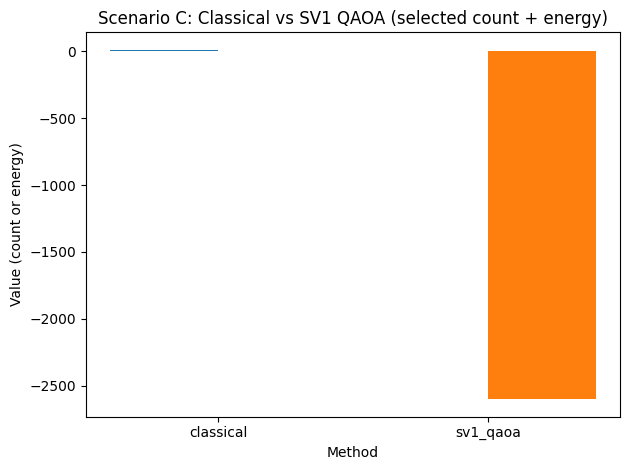

Saved figure: outputs/figures/09d_scenario_C_compare_selected_count_and_energy.png


In [7]:
# ============================================================
# Cell 4 — Export compare CSV + generate a clean comparison figure
# ============================================================

compare_df.to_csv(OUT_COMPARE, index=False)
print("Wrote compare table:", OUT_COMPARE)

methods = compare_df["method"].tolist()
selected_counts = compare_df["selected_n"].astype(float).tolist()
energies = compare_df["energy"].astype(float).tolist()

x = np.arange(len(methods))

plt.figure()
plt.bar(x - 0.2, selected_counts, width=0.4)
plt.bar(x + 0.2, energies, width=0.4)
plt.xticks(x, methods)
plt.title("Scenario C: Classical vs SV1 QAOA (selected count + energy)")
plt.xlabel("Method")
plt.ylabel("Value (count or energy)")
plt.tight_layout()
plt.savefig(OUT_FIG, dpi=160)
plt.show()

print("Saved figure:", OUT_FIG)


### What Cell 4 Just Did

- Exported the method-level comparison table to `data/results/09d_compare_classical_vs_sv1_scenario_C.csv`.
- Created and saved a simple figure summarizing Scenario C:
  - selected trial count and “energy” for classical vs SV1 QAOA.
- Saved the figure to `outputs/figures/09d_scenario_C_compare_selected_count_and_energy.png`.


## Summary

Scenario C comparison is complete:

- `data/results/09d_compare_classical_vs_sv1_scenario_C.csv`
  - Method-level comparison (energy + selected_n; includes SV1 metadata if available).
- `data/results/09d_overlap_classical_vs_sv1_scenario_C.csv`
  - The overlapping selected trials (intersection set).
- `outputs/figures/09d_scenario_C_compare_selected_count_and_energy.png`
  - One simple figure you can drop into README and slides.

Next step:
- Push `09d_compare_classical_vs_sv1_scenario_C.ipynb` + the two CSVs + the figure to GitHub.
